# Keras TF 2.0 - Code Along Classification Project

Let's explore a classification task with Keras API for TF 2.0

## The Data

### Breast cancer wisconsin (diagnostic) dataset
--------------------------------------------

**Data Set Characteristics:**

    :Number of Instances: 569

    :Number of Attributes: 30 numeric, predictive attributes and the class

    :Attribute Information:
        - radius (mean of distances from center to points on the perimeter)
        - texture (standard deviation of gray-scale values)
        - perimeter
        - area
        - smoothness (local variation in radius lengths)
        - compactness (perimeter^2 / area - 1.0)
        - concavity (severity of concave portions of the contour)
        - concave points (number of concave portions of the contour)
        - symmetry 
        - fractal dimension ("coastline approximation" - 1)

        The mean, standard error, and "worst" or largest (mean of the three
        largest values) of these features were computed for each image,
        resulting in 30 features.  For instance, field 3 is Mean Radius, field
        13 is Radius SE, field 23 is Worst Radius.

        - class:
                - WDBC-Malignant
                - WDBC-Benign

    :Summary Statistics:

    ===================================== ====== ======
                                           Min    Max
    ===================================== ====== ======
    radius (mean):                        6.981  28.11
    texture (mean):                       9.71   39.28
    perimeter (mean):                     43.79  188.5
    area (mean):                          143.5  2501.0
    smoothness (mean):                    0.053  0.163
    compactness (mean):                   0.019  0.345
    concavity (mean):                     0.0    0.427
    concave points (mean):                0.0    0.201
    symmetry (mean):                      0.106  0.304
    fractal dimension (mean):             0.05   0.097
    radius (standard error):              0.112  2.873
    texture (standard error):             0.36   4.885
    perimeter (standard error):           0.757  21.98
    area (standard error):                6.802  542.2
    smoothness (standard error):          0.002  0.031
    compactness (standard error):         0.002  0.135
    concavity (standard error):           0.0    0.396
    concave points (standard error):      0.0    0.053
    symmetry (standard error):            0.008  0.079
    fractal dimension (standard error):   0.001  0.03
    radius (worst):                       7.93   36.04
    texture (worst):                      12.02  49.54
    perimeter (worst):                    50.41  251.2
    area (worst):                         185.2  4254.0
    smoothness (worst):                   0.071  0.223
    compactness (worst):                  0.027  1.058
    concavity (worst):                    0.0    1.252
    concave points (worst):               0.0    0.291
    symmetry (worst):                     0.156  0.664
    fractal dimension (worst):            0.055  0.208
    ===================================== ====== ======

    :Missing Attribute Values: None

    :Class Distribution: 212 - Malignant, 357 - Benign

    :Creator:  Dr. William H. Wolberg, W. Nick Street, Olvi L. Mangasarian

    :Donor: Nick Street

    :Date: November, 1995

In [93]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [94]:
from sklearn.datasets import load_breast_cancer

cancer = load_breast_cancer()
df = pd.DataFrame(cancer['data'], columns=cancer['feature_names'])
df['benign_0__mal_1'] = cancer['target']

In [95]:
df

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,benign_0__mal_1
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.16220,0.66560,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.12380,0.18660,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.14440,0.42450,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.20980,0.86630,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.13740,0.20500,0.4000,0.1625,0.2364,0.07678,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,0.1726,0.05623,...,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115,0
565,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,0.1752,0.05533,...,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637,0
566,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,0.1590,0.05648,...,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820,0
567,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,0.2397,0.07016,...,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400,0


In [96]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    float64
 14  smoothness error         5

In [97]:
df.describe().T


,count,mean,std,min,25%,50%,75%,max
mean radius,569.0,14.127292,3.524049,6.981000,11.700000,13.370000,15.780000,28.11000
mean texture,569.0,19.289649,4.301036,9.710000,16.170000,18.840000,21.800000,39.28000
mean perimeter,569.0,91.969033,24.298981,43.790000,75.170000,86.240000,104.100000,188.50000
mean area,569.0,654.889104,351.914129,143.500000,420.300000,551.100000,782.700000,2501.00000
mean smoothness,569.0,0.096360,0.014064,0.052630,0.086370,0.095870,0.105300,0.16340
mean compactness,569.0,0.104341,0.052813,0.019380,0.064920,0.092630,0.130400,0.34540
mean concavity,569.0,0.088799,0.079720,0.000000,0.029560,0.061540,0.130700,0.42680
mean concave points,569.0,0.048919,0.038803,0.000000,0.020310,0.033500,0.074000,0.20120
mean symmetry,569.0,0.181162,0.027414,0.106000,0.161900,0.179200,0.195700,0.30400
mean fractal dimension,569.0,0.062798,0.007060,0.049960,0.057700,0.061540,0.066120,0.09744


## EDA

In [98]:
import seaborn as sns
import matplotlib.pyplot as plt

<Axes: xlabel='benign_0__mal_1', ylabel='count'>

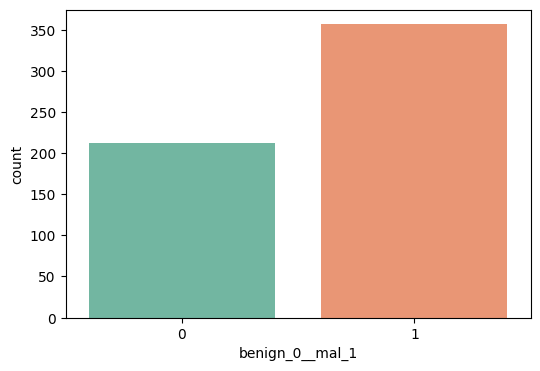

In [99]:
plt.figure(figsize=(6,4))
sns.countplot(x='benign_0__mal_1', data=df, palette="Set2")

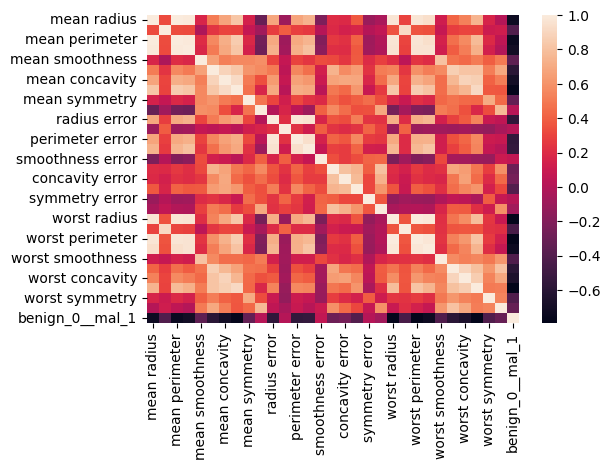

In [100]:
plt.figure(figsize=(6,4))
sns.heatmap(df.corr())
plt.show()

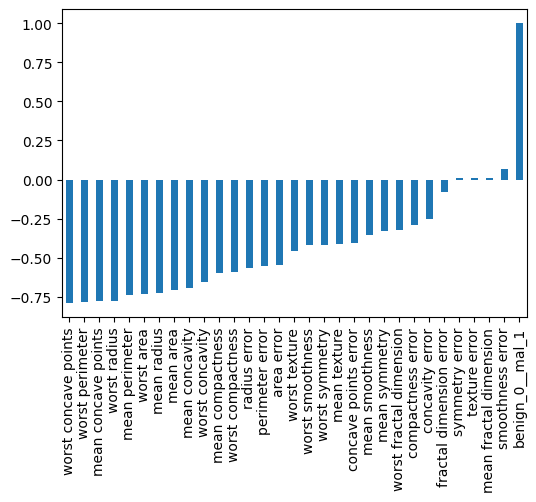

In [101]:
# Based on 'benign_0__mal_1'
corr = df.corr()['benign_0__mal_1'].sort_values()
plt.figure(figsize=(6,4))
corr.plot(kind='bar')
plt.show()

## Train Test Split

In [102]:
from sklearn.model_selection import train_test_split

In [103]:
x = df.drop('benign_0__mal_1', axis=1).values
y = df['benign_0__mal_1'].values
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)


## Scaling Data

In [104]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()   
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)


## Creating the Model

    # For a binary classification problem
    model.compile(optimizer='rmsprop',
                  loss='binary_crossentropy',
                  metrics=['accuracy'])
                  
    

In [105]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Activation

In [106]:
model = Sequential()
model.add(Dense(30, activation='relu'))
model.add(Dense(15, activation='relu'))
model.add(Dense(1, activation='sigmoid'))
model.compile(loss='binary_crossentropy', optimizer='rmsprop', metrics=['accuracy'])


## Training the Model 

### Example One: Choosing too many epochs and overfitting!

In [107]:
model.fit(x=x_train,y= y_train, epochs=900, validation_data=(x_test, y_test))

Epoch 1/900
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.6319 - loss: 0.7098 - val_accuracy: 0.6667 - val_loss: 0.6397
Epoch 2/900
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7202 - loss: 0.6394 - val_accuracy: 0.7807 - val_loss: 0.5865
Epoch 3/900
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7859 - loss: 0.5803 - val_accuracy: 0.9298 - val_loss: 0.5375
Epoch 4/900
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8518 - loss: 0.5380 - val_accuracy: 0.9298 - val_loss: 0.4908
Epoch 5/900
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8673 - loss: 0.5003 - val_accuracy: 0.8333 - val_loss: 0.4481
Epoch 6/900
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8828 - loss: 0.4383 - val_accuracy: 0.9211 - val_loss: 0.4009
Epoch 7/900
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8903 - loss: 0.4257 - val_accuracy: 0.8772 - val_loss: 0.3694
Epoch 8/900
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8818 - loss: 0.3816 - val_accuracy: 0.9298 - v

Train on 426 samples, validate on 143 samples
Epoch 1/600
426/426 [==============================] - 0s 964us/sample - loss: 0.6673 - val_loss: 0.6458
Epoch 2/600
426/426 [==============================] - 0s 102us/sample - loss: 0.6248 - val_loss: 0.6064
Epoch 3/600
426/426 [==============================] - 0s 98us/sample - loss: 0.5845 - val_loss: 0.5600
Epoch 4/600
426/426 [==============================] - 0s 101us/sample - loss: 0.5380 - val_loss: 0.5073
Epoch 5/600
426/426 [==============================] - 0s 103us/sample - loss: 0.4830 - val_loss: 0.4450
Epoch 6/600
426/426 [==============================] - 0s 97us/sample - loss: 0.4236 - val_loss: 0.3856
Epoch 7/600
426/426 [==============================] - 0s 103us/sample - loss: 0.3735 - val_loss: 0.3394
Epoch 8/600
426/426 [==============================] - 0s 99us/sample - loss: 0.3336 - val_loss: 0.3020
Epoch 9/600
426/426 [==============================] - 0s 101us/sample - loss: 0.3002 - val_loss: 0.2729
Epoch 10/600

426/426 [==============================] - 0s 94us/sample - loss: 0.0399 - val_loss: 0.1443
Epoch 156/600
426/426 [==============================] - 0s 98us/sample - loss: 0.0407 - val_loss: 0.1392
Epoch 157/600
426/426 [==============================] - 0s 94us/sample - loss: 0.0396 - val_loss: 0.1438
Epoch 158/600
426/426 [==============================] - 0s 96us/sample - loss: 0.0405 - val_loss: 0.1420
Epoch 159/600
426/426 [==============================] - 0s 94us/sample - loss: 0.0415 - val_loss: 0.1415
Epoch 160/600
426/426 [==============================] - 0s 94us/sample - loss: 0.0392 - val_loss: 0.1436
Epoch 161/600
426/426 [==============================] - 0s 93us/sample - loss: 0.0396 - val_loss: 0.1379
Epoch 162/600
426/426 [==============================] - 0s 98us/sample - loss: 0.0402 - val_loss: 0.1473
Epoch 163/600
426/426 [==============================] - 0s 91us/sample - loss: 0.0414 - val_loss: 0.1449
Epoch 164/600
426/426 [==============================] - 0s 

426/426 [==============================] - 0s 99us/sample - loss: 0.0409 - val_loss: 0.1652
Epoch 310/600
426/426 [==============================] - 0s 99us/sample - loss: 0.0312 - val_loss: 0.1590
Epoch 311/600
426/426 [==============================] - 0s 96us/sample - loss: 0.0291 - val_loss: 0.1667
Epoch 312/600
426/426 [==============================] - 0s 92us/sample - loss: 0.0268 - val_loss: 0.1658
Epoch 313/600
426/426 [==============================] - 0s 99us/sample - loss: 0.0269 - val_loss: 0.1647
Epoch 314/600
426/426 [==============================] - 0s 94us/sample - loss: 0.0267 - val_loss: 0.1750
Epoch 315/600
426/426 [==============================] - 0s 98us/sample - loss: 0.0289 - val_loss: 0.1645
Epoch 316/600
426/426 [==============================] - 0s 96us/sample - loss: 0.0263 - val_loss: 0.1651
Epoch 317/600
426/426 [==============================] - 0s 95us/sample - loss: 0.0271 - val_loss: 0.1685
Epoch 318/600
426/426 [==============================] - 0s 

426/426 [==============================] - 0s 95us/sample - loss: 0.0159 - val_loss: 0.2318
Epoch 464/600
426/426 [==============================] - 0s 99us/sample - loss: 0.0158 - val_loss: 0.2159
Epoch 465/600
426/426 [==============================] - 0s 98us/sample - loss: 0.0150 - val_loss: 0.2128
Epoch 466/600
426/426 [==============================] - 0s 101us/sample - loss: 0.0188 - val_loss: 0.2280
Epoch 467/600
426/426 [==============================] - 0s 98us/sample - loss: 0.0148 - val_loss: 0.2164
Epoch 468/600
426/426 [==============================] - 0s 105us/sample - loss: 0.0178 - val_loss: 0.2127
Epoch 469/600
426/426 [==============================] - 0s 102us/sample - loss: 0.0177 - val_loss: 0.2232
Epoch 470/600
426/426 [==============================] - 0s 96us/sample - loss: 0.0149 - val_loss: 0.2276
Epoch 471/600
426/426 [==============================] - 0s 98us/sample - loss: 0.0147 - val_loss: 0.2184
Epoch 472/600
426/426 [==============================] - 

Epoch 540/600
426/426 [==============================] - 0s 98us/sample - loss: 0.0126 - val_loss: 0.2521
Epoch 541/600
426/426 [==============================] - 0s 99us/sample - loss: 0.0116 - val_loss: 0.2455
Epoch 542/600
426/426 [==============================] - 0s 98us/sample - loss: 0.0132 - val_loss: 0.2970
Epoch 543/600
426/426 [==============================] - 0s 101us/sample - loss: 0.0172 - val_loss: 0.2415
Epoch 544/600
426/426 [==============================] - 0s 103us/sample - loss: 0.0183 - val_loss: 0.2610
Epoch 545/600
426/426 [==============================] - 0s 108us/sample - loss: 0.0125 - val_loss: 0.2543
Epoch 546/600
426/426 [==============================] - 0s 95us/sample - loss: 0.0163 - val_loss: 0.2473
Epoch 547/600
426/426 [==============================] - 0s 103us/sample - loss: 0.0139 - val_loss: 0.2642
Epoch 548/600
426/426 [==============================] - 0s 102us/sample - loss: 0.0134 - val_loss: 0.2489
Epoch 549/600
426/426 [==================

In [108]:
model.history.history

{'accuracy': [0.6241758465766907,
  0.7494505643844604,
  0.797802209854126,
  0.8483516573905945,
  0.8681318759918213,
  0.8747252821922302,
  0.894505500793457,
  0.8879120945930481,
  0.9054945111274719,
  0.9054945111274719,
  0.901098906993866,
  0.9076923131942749,
  0.903296709060669,
  0.9186813235282898,
  0.9252747297286987,
  0.9164835214614868,
  0.9164835214614868,
  0.9164835214614868,
  0.9230769276618958,
  0.9318681359291077,
  0.9208791255950928,
  0.9340659379959106,
  0.9274725317955017,
  0.9340659379959106,
  0.9362637400627136,
  0.9516483545303345,
  0.9450549483299255,
  0.9560439586639404,
  0.9626373648643494,
  0.9670329689979553,
  0.9560439586639404,
  0.9604395627975464,
  0.9626373648643494,
  0.9648351669311523,
  0.9714285731315613,
  0.9648351669311523,
  0.9626373648643494,
  0.9670329689979553,
  0.9736263751983643,
  0.9648351669311523,
  0.9648351669311523,
  0.9692307710647583,
  0.9758241772651672,
  0.9692307710647583,
  0.9714285731315613,
  

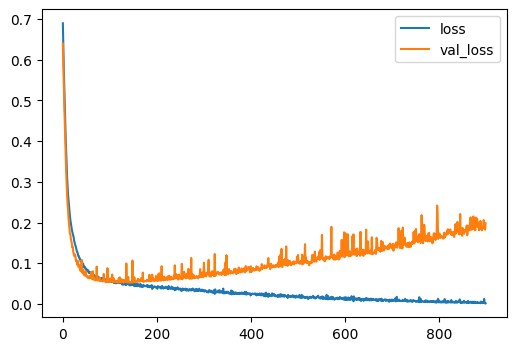

In [112]:
# model_loss
plt.figure(figsize=(6,4))

plt.plot(model.history.history['loss'], label='loss')
plt.plot(model.history.history['val_loss'], label='val_loss')

plt.legend()
plt.show()

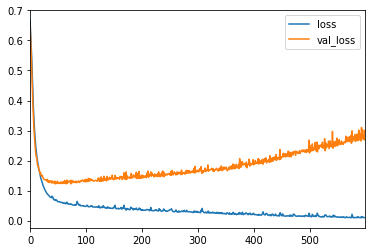

In [116]:
model_loss.plot()

## Example Two: Early Stopping

We obviously trained too much! Let's use early stopping to track the val_loss and stop training once it begins increasing too much!

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping

Stop training when a monitored quantity has stopped improving.

    Arguments:
        monitor: Quantity to be monitored.
        min_delta: Minimum change in the monitored quantity
            to qualify as an improvement, i.e. an absolute
            change of less than min_delta, will count as no
            improvement.
        patience: Number of epochs with no improvement
            after which training will be stopped.
        verbose: verbosity mode.
        mode: One of `{"auto", "min", "max"}`. In `min` mode,
            training will stop when the quantity
            monitored has stopped decreasing; in `max`
            mode it will stop when the quantity
            monitored has stopped increasing; in `auto`
            mode, the direction is automatically inferred
            from the name of the monitored quantity.

Train on 426 samples, validate on 143 samples
Epoch 1/600
426/426 [==============================] - 0s 967us/sample - loss: 0.6927 - val_loss: 0.6778
Epoch 2/600
426/426 [==============================] - 0s 103us/sample - loss: 0.6653 - val_loss: 0.6505
Epoch 3/600
426/426 [==============================] - 0s 104us/sample - loss: 0.6330 - val_loss: 0.6182
Epoch 4/600
426/426 [==============================] - 0s 102us/sample - loss: 0.5982 - val_loss: 0.5789
Epoch 5/600
426/426 [==============================] - 0s 98us/sample - loss: 0.5523 - val_loss: 0.5269
Epoch 6/600
426/426 [==============================] - 0s 100us/sample - loss: 0.4953 - val_loss: 0.4664
Epoch 7/600
426/426 [==============================] - 0s 105us/sample - loss: 0.4343 - val_loss: 0.4037
Epoch 8/600
426/426 [==============================] - 0s 99us/sample - loss: 0.3751 - val_loss: 0.3478
Epoch 9/600
426/426 [==============================] - 0s 100us/sample - loss: 0.3233 - val_loss: 0.2980
Epoch 10/60

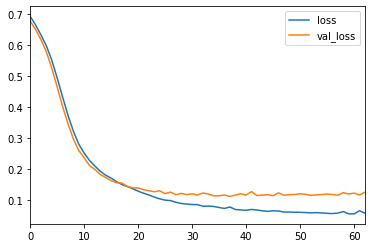

## Example Three: Adding in DropOut Layers

In [125]:
from tensorflow.keras.layers import Dropout

Train on 426 samples, validate on 143 samples
Epoch 1/600
426/426 [==============================] - 0s 1ms/sample - loss: 0.6894 - val_loss: 0.6833
Epoch 2/600
426/426 [==============================] - 0s 101us/sample - loss: 0.6828 - val_loss: 0.6722
Epoch 3/600
426/426 [==============================] - 0s 103us/sample - loss: 0.6817 - val_loss: 0.6584
Epoch 4/600
426/426 [==============================] - 0s 99us/sample - loss: 0.6626 - val_loss: 0.6439
Epoch 5/600
426/426 [==============================] - 0s 97us/sample - loss: 0.6450 - val_loss: 0.6319
Epoch 6/600
426/426 [==============================] - 0s 101us/sample - loss: 0.6343 - val_loss: 0.6138
Epoch 7/600
426/426 [==============================] - 0s 108us/sample - loss: 0.6207 - val_loss: 0.5962
Epoch 8/600
426/426 [==============================] - 0s 103us/sample - loss: 0.6005 - val_loss: 0.5744
Epoch 9/600
426/426 [==============================] - 0s 103us/sample - loss: 0.5897 - val_loss: 0.5444
Epoch 10/600


426/426 [==============================] - 0s 98us/sample - loss: 0.1228 - val_loss: 0.1019
Epoch 79/600
426/426 [==============================] - 0s 103us/sample - loss: 0.1097 - val_loss: 0.0958
Epoch 80/600
426/426 [==============================] - 0s 104us/sample - loss: 0.1086 - val_loss: 0.0939
Epoch 81/600
426/426 [==============================] - 0s 102us/sample - loss: 0.1100 - val_loss: 0.0974
Epoch 82/600
426/426 [==============================] - 0s 107us/sample - loss: 0.1394 - val_loss: 0.0995
Epoch 83/600
426/426 [==============================] - 0s 110us/sample - loss: 0.1069 - val_loss: 0.0951
Epoch 84/600
426/426 [==============================] - 0s 108us/sample - loss: 0.1095 - val_loss: 0.0961
Epoch 85/600
426/426 [==============================] - 0s 108us/sample - loss: 0.1262 - val_loss: 0.0995
Epoch 86/600
426/426 [==============================] - 0s 105us/sample - loss: 0.1187 - val_loss: 0.1073
Epoch 87/600
426/426 [==============================] - 0s 9

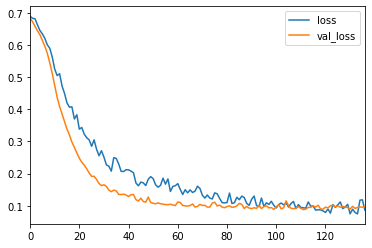

# Model Evaluation

In [130]:
from sklearn.metrics import classification_report,confusion_matrix

              precision    recall  f1-score   support

           0       0.96      0.98      0.97        55
           1       0.99      0.98      0.98        88

    accuracy                           0.98       143
   macro avg       0.98      0.98      0.98       143
weighted avg       0.98      0.98      0.98       143



[[54  1]
 [ 2 86]]
